## Micro-cap Stock Delisting-Risk Classification Using Random Forest

The objective of this project is to classify NSE-listed companies into Low-Risk and High-Risk delisting categories using the security master data (symbol, ISIN, company name, listing date, active status). Random Forest is used to classify risk based on structural/text attributes of the listing.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)


## Load and understand the original dataset

In [2]:
df = pd.read_csv("nse_security_master_rf.csv")
df.head()

,nse_symbol,isin,company_name,listing_date,active_flag
0,20MICRONS,INE144J01027,20 MICRONS LIMITED,06-10-2008,True
1,21STCENMGM,INE253B01015,21ST CENTURY MANAGEMENT SERVICES LIMITED,03-05-1995,True
2,360ONE,INE466L01038,360 ONE WAM LIMITED,19-09-2019,True
3,3BBLACKBIO,INE994E01018,3B BLACKBIO DX LIMITED,20-04-2026,True
4,3IINFOLTD,INE748C01038,3I INFOTECH LIMITED,22-10-2021,True


In [3]:
df.shape

(2389, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nse_symbol    2389 non-null   object
 1   isin          2389 non-null   object
 2   company_name  2389 non-null   object
 3   listing_date  2389 non-null   object
 4   active_flag   2389 non-null   bool  
dtypes: bool(1), object(4)
memory usage: 77.1+ KB


In [5]:
df.isnull().sum()

nse_symbol      0
isin            0
company_name    0
listing_date    0
active_flag     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

##### No missing values, no duplicates. 2,389 companies, 5 raw columns.

In [7]:
# convert listing_date to datetime
df['listing_date'] = pd.to_datetime(df['listing_date'], format='%d-%m-%Y')
df.dtypes

nse_symbol              object
isin                    object
company_name            object
listing_date    datetime64[ns]
active_flag               bool
dtype: object

In [8]:
df['active_flag'].value_counts()

active_flag
True    2389
Name: count, dtype: int64

##### `active_flag` is `True` for every single row in this file - there are no delisted companies here, so it can't be used directly as a target. This dataset only tells us who's currently listed and since when.

## Create the target variable (proxy, not real delisting labels)

Since there's no ground-truth delisted-company data in this file, I'm building a **proxy risk label** by using a median split of an engineered metric, `listing_tenure_years`.

**Assumption / caveat:** companies with a shorter listing track record (below-median tenure) are labeled `High Risk`, and longer-established companies (above-median tenure) are labeled `Low Risk`. This is a reasonable stand-in for delisting risk (newer, less-proven listings) but it is **not real delisting outcome data** - treat the results below as a demonstration of the RF workflow, not a real risk score.

In [9]:
df['listing_tenure_years'] = (pd.Timestamp('2026-09-01') - df['listing_date']).dt.days / 365.25
median_tenure = df['listing_tenure_years'].median()
print(median_tenure)

10.466803559206022


In [10]:
# High risk (1) = below-median tenure (newer listing, shorter track record)
df['delisting_risk'] = (df['listing_tenure_years'] < median_tenure).astype(int)
df['delisting_risk'].value_counts()

delisting_risk
0    1195
1    1194
Name: count, dtype: int64

##### Median split gives a balanced target, as expected.

## Feature engineering

Only text/structural fields are available (`nse_symbol`, `company_name`, `isin`), so features are built from those. Anything directly derived from `listing_date` (like `listing_tenure_years` or `listing_year`) is deliberately **excluded from the feature set** since that's what the target was built from - using it as a predictor would just leak the label back in.

In [11]:
df['symbol_length'] = df['nse_symbol'].str.len()
df['company_name_length'] = df['company_name'].str.len()
df['name_word_count'] = df['company_name'].str.split().str.len()
df['is_limited'] = df['company_name'].str.upper().str.contains('LIMITED|LTD').astype(int)
df['symbol_starts_digit'] = df['nse_symbol'].str[0].str.isdigit().astype(int)

df[['nse_symbol','company_name','symbol_length','company_name_length',
    'name_word_count','is_limited','symbol_starts_digit','delisting_risk']].head()

,nse_symbol,company_name,symbol_length,company_name_length,name_word_count,is_limited,symbol_starts_digit,delisting_risk
0,20MICRONS,20 MICRONS LIMITED,9,18,3,1,1,0
1,21STCENMGM,21ST CENTURY MANAGEMENT SERVICES LIMITED,10,40,5,1,1,0
2,360ONE,360 ONE WAM LIMITED,6,19,4,1,1,1
3,3BBLACKBIO,3B BLACKBIO DX LIMITED,10,22,4,1,1,1
4,3IINFOLTD,3I INFOTECH LIMITED,9,19,3,1,1,1


## EDA:
Here we analyze the engineered attributes against the delisting-risk proxy.

### 1. Distribution of listing year
When most of the currently-active companies on the exchange were listed.

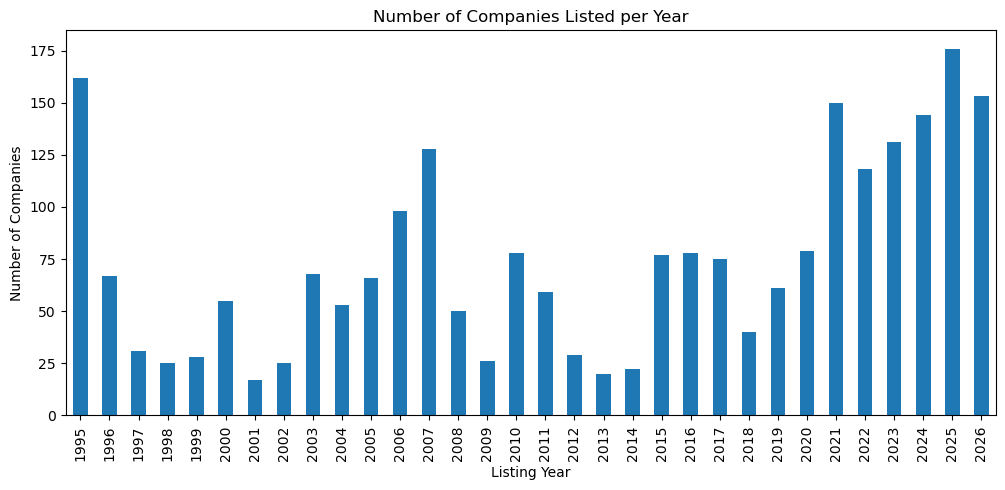

In [12]:
plt.figure(figsize=(12, 5))
df['listing_date'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Number of Companies Listed per Year")
plt.xlabel("Listing Year")
plt.ylabel("Number of Companies")
plt.show()

### 2. Distribution of listing tenure (years)

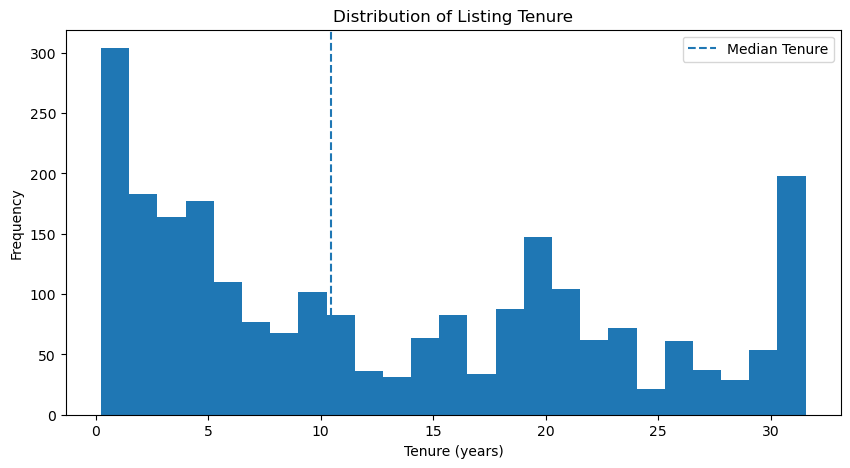

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df['listing_tenure_years'], bins=25)
plt.axvline(median_tenure, linestyle='--', label='Median Tenure')
plt.title("Distribution of Listing Tenure")
plt.xlabel("Tenure (years)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Distribution of the delisting-risk proxy

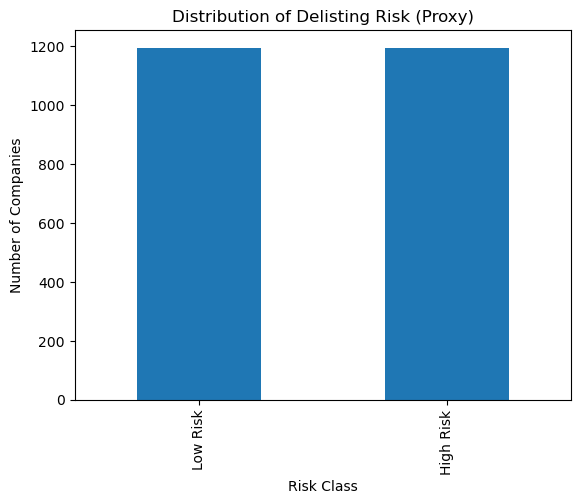

In [14]:
df['delisting_risk'].value_counts().plot(kind='bar')
plt.title("Distribution of Delisting Risk (Proxy)")
plt.xlabel("Risk Class")
plt.ylabel("Number of Companies")
plt.xticks([0, 1], ["Low Risk", "High Risk"])
plt.show()

### 4. Correlation heatmap of engineered numeric features

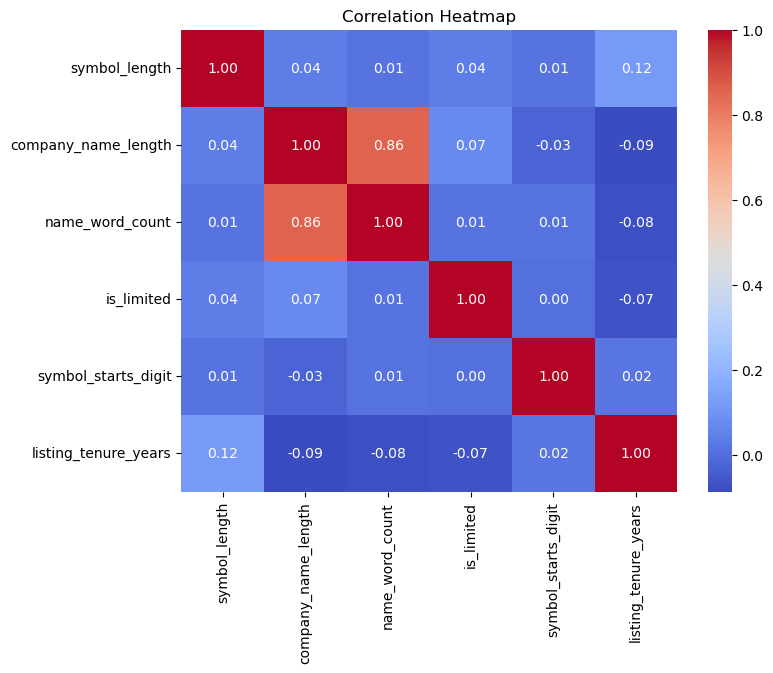

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['symbol_length','company_name_length','name_word_count',
        'is_limited','symbol_starts_digit','listing_tenure_years']].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

### Simple interpretation:
All the text-based features have weak correlation with tenure (roughly -0.09 to 0.12). That's expected - company name/symbol length say very little about how long a stock has been listed. This is a useful honesty check before modeling: the signal here is going to be modest, not strong.

### 5. Company name length by risk class

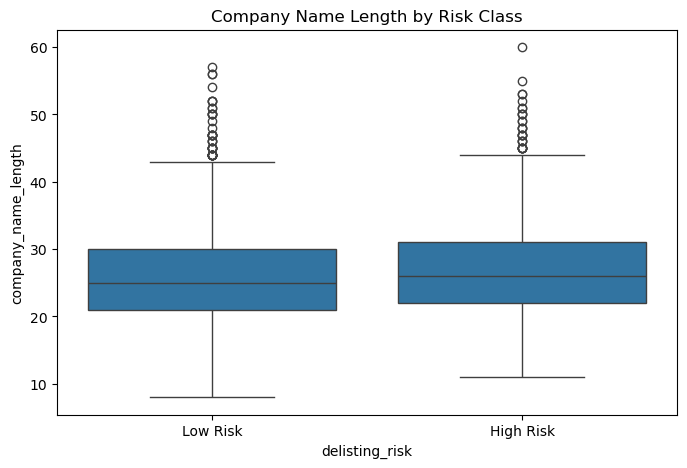

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='delisting_risk', y='company_name_length', data=df)
plt.xticks([0, 1], ["Low Risk", "High Risk"])
plt.title("Company Name Length by Risk Class")
plt.show()

### Create Model: `delisting_risk` is the target our Random Forest will predict.
**Separate x and y**

In [17]:
x = df[['symbol_length','company_name_length','name_word_count',
        'is_limited','symbol_starts_digit']]
y = df['delisting_risk']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (2389, 5)
Target shape: (2389,)


### Train-test split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1911, 5)
Testing data: (478, 5)


#### Why stratify?
The target isn't tied to a strict time order, so a stratified split (rather than a chronological one) keeps the class balance consistent between train and test.

### Training first Random Forest model:
First, let's start with `n_estimators = 100`:

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make predictions

In [20]:
y_pred = rf.predict(x_test)

### Now compare the predicted values with the actual target:

In [21]:
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results.head()

,Actual,Predicted
1494,1,1
1560,0,0
748,1,1
2148,0,0
1939,0,0


### Evaluate the first Random Forest model

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.5920502092050209


In [23]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[159  80]
 [115 124]]


In [24]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
delisting_risk
0    0.500262
1    0.499738
Name: proportion, dtype: float64

Testing target distribution:
delisting_risk
1    0.5
0    0.5
Name: proportion, dtype: float64


In [25]:
print("Training score:", round(rf.score(x_train, y_train), 4))
print("Testing score:", round(rf.score(x_test, y_test), 4))

Training score: 0.7091
Testing score: 0.5921


##### Training score is noticeably higher than testing score - a sign that a single deep, unrestricted tree ensemble is overfitting the small feature set. That's exactly what the hyperparameter sweep below should help diagnose.

### Now find good hyperparameters / improve the Random Forest model
Instead of arbitrarily picking `n_estimators = 100`, sweep across a range and track how metrics move.

In [26]:
n_values = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for n in range(10, 210, 20):
    rf = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    n_values.append(n)
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

    print(f"n_estimators = {n:<3} | Accuracy = {acc:.4f} | Precision = {prec:.4f} | Recall = {rec:.4f} | F1 Score = {f1:.4f}")

n_estimators = 10  | Accuracy = 0.6151 | Precision = 0.6087 | Recall = 0.6444 | F1 Score = 0.6260
n_estimators = 30  | Accuracy = 0.6067 | Precision = 0.6016 | Recall = 0.6318 | F1 Score = 0.6163
n_estimators = 50  | Accuracy = 0.6172 | Precision = 0.6129 | Recall = 0.6360 | F1 Score = 0.6242
n_estimators = 70  | Accuracy = 0.6130 | Precision = 0.6080 | Recall = 0.6360 | F1 Score = 0.6217
n_estimators = 90  | Accuracy = 0.6130 | Precision = 0.6089 | Recall = 0.6318 | F1 Score = 0.6201
n_estimators = 110 | Accuracy = 0.6109 | Precision = 0.6064 | Recall = 0.6318 | F1 Score = 0.6189
n_estimators = 130 | Accuracy = 0.6088 | Precision = 0.6048 | Recall = 0.6276 | F1 Score = 0.6160
n_estimators = 150 | Accuracy = 0.6088 | Precision = 0.6048 | Recall = 0.6276 | F1 Score = 0.6160
n_estimators = 170 | Accuracy = 0.6088 | Precision = 0.6040 | Recall = 0.6318 | F1 Score = 0.6176
n_estimators = 190 | Accuracy = 0.6130 | Precision = 0.6089 | Recall = 0.6318 | F1 Score = 0.6201


n_estimators = 50  | Accuracy = 0.6172 | Precision = 0.6129 | Recall = 0.6360 | F1 Score = 0.6242


n_estimators = 70  | Accuracy = 0.6130 | Precision = 0.6080 | Recall = 0.6360 | F1 Score = 0.6217


n_estimators = 90  | Accuracy = 0.6130 | Precision = 0.6089 | Recall = 0.6318 | F1 Score = 0.6201


n_estimators = 110 | Accuracy = 0.6109 | Precision = 0.6064 | Recall = 0.6318 | F1 Score = 0.6189


n_estimators = 130 | Accuracy = 0.6088 | Precision = 0.6048 | Recall = 0.6276 | F1 Score = 0.6160


n_estimators = 150 | Accuracy = 0.6088 | Precision = 0.6048 | Recall = 0.6276 | F1 Score = 0.6160


n_estimators = 170 | Accuracy = 0.6088 | Precision = 0.6040 | Recall = 0.6318 | F1 Score = 0.6176


n_estimators = 190 | Accuracy = 0.6130 | Precision = 0.6089 | Recall = 0.6318 | F1 Score = 0.6201


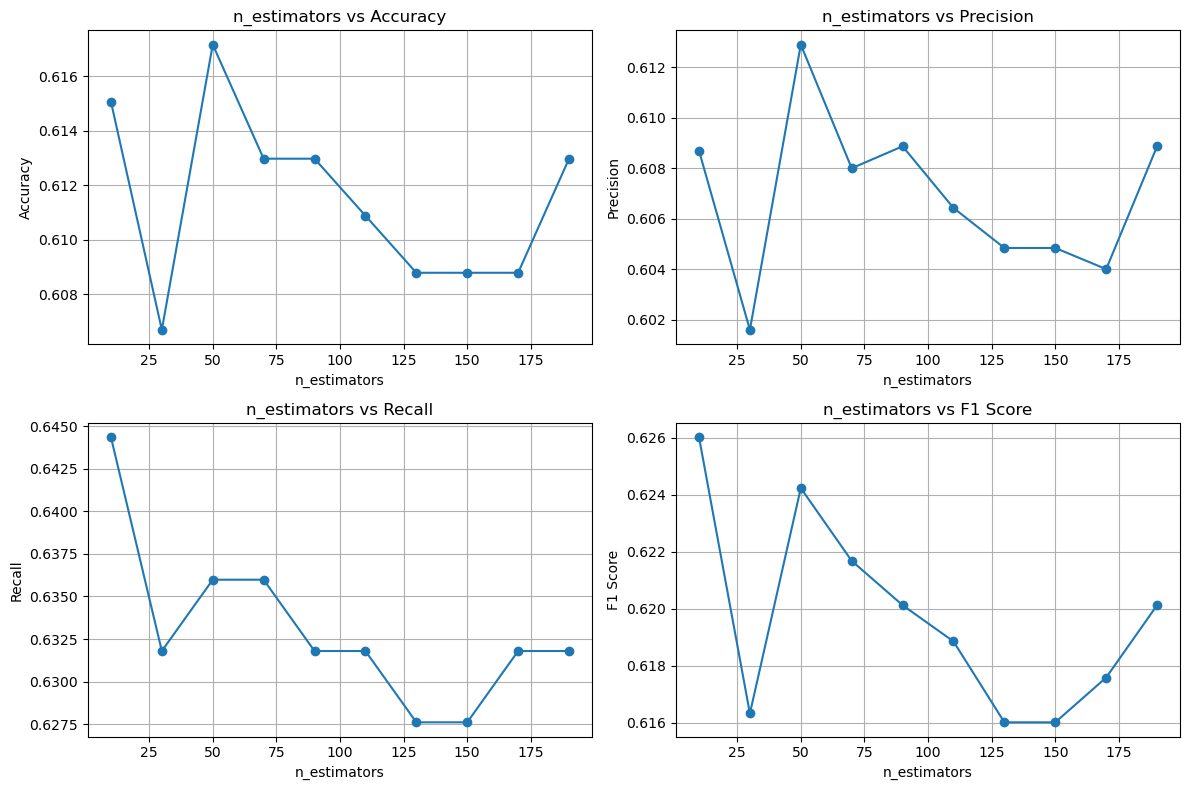

In [27]:
# Plot metric vs n_estimators (max_depth fixed at 5)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(n_values, accuracy_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("n_estimators vs Accuracy")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(n_values, precision_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Precision")
plt.title("n_estimators vs Precision")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(n_values, recall_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Recall")
plt.title("n_estimators vs Recall")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(n_values, f1_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("F1 Score")
plt.title("n_estimators vs F1 Score")
plt.grid()

plt.tight_layout()
plt.show()

### Now sweep `max_depth` (with `n_estimators` fixed) to control overfitting

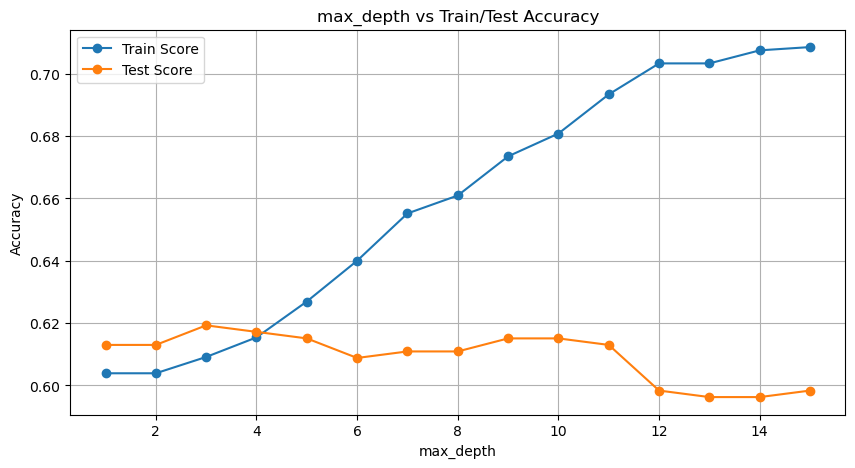

In [28]:
depth_values = []
train_scores = []
test_scores = []

for d in range(1, 16):
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(x_train, y_train)

    depth_values.append(d)
    train_scores.append(rf.score(x_train, y_train))
    test_scores.append(rf.score(x_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depth_values, train_scores, marker='o', label="Train Score")
plt.plot(depth_values, test_scores, marker='o', label="Test Score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("max_depth vs Train/Test Accuracy")
plt.legend()
plt.grid()
plt.show()

##### Insight: train accuracy keeps climbing with depth while test accuracy flattens out early - the gap widening is the overfitting signature. The depth just before the gap opens up is the better pick, not the depth with the highest train score.

In [29]:
for d in [3, 5, 8]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    print("max_depth =", d)
    print("Classification report:\n", classification_report(y_test, y_pred), end="\n\n")

max_depth = 3
Classification report:
               precision    recall  f1-score   support

           0       0.63      0.57      0.60       239
           1       0.61      0.67      0.64       239

    accuracy                           0.62       478
   macro avg       0.62      0.62      0.62       478
weighted avg       0.62      0.62      0.62       478


max_depth = 5
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.59      0.61       239
           1       0.61      0.64      0.62       239

    accuracy                           0.62       478
   macro avg       0.62      0.62      0.61       478
weighted avg       0.62      0.62      0.61       478


max_depth = 8
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.58      0.60       239
           1       0.60      0.64      0.62       239

    accuracy                           0.61       478
   macro avg

max_depth = 8
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.58      0.60       239
           1       0.60      0.64      0.62       239

    accuracy                           0.61       478
   macro avg       0.61      0.61      0.61       478
weighted avg       0.61      0.61      0.61       478




In [30]:
for d in [3, 5, 8]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    roc_auc = roc_auc_score(y_test, y_pred)
    print("max_depth =", d, "ROC_AUC =", roc_auc)

max_depth = 3 ROC_AUC = 0.6192468619246863
max_depth = 5 ROC_AUC = 0.615062761506276
max_depth = 8 ROC_AUC = 0.6108786610878661


max_depth = 5 ROC_AUC = 0.615062761506276


max_depth = 8 ROC_AUC = 0.6108786610878661


### Feature importance
Which engineered features the final model actually relies on.

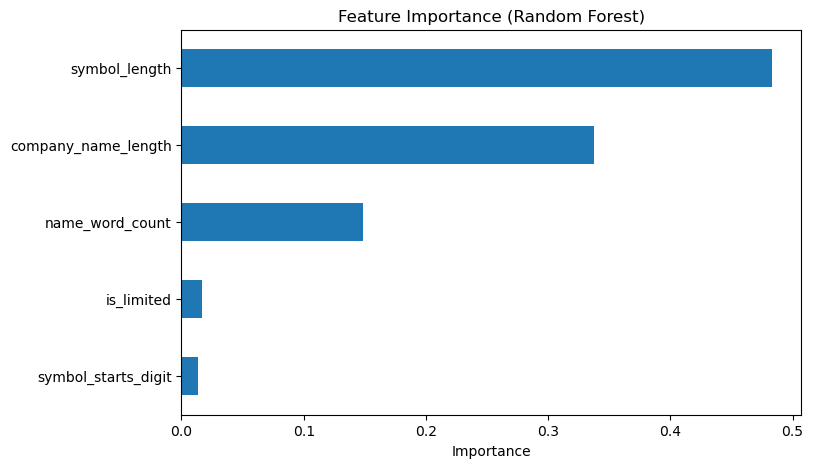

In [31]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(x_train, y_train)

importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

### Final model + insight

**Chosen setting:** `n_estimators = 100`, `max_depth = 5` - accuracy/F1 stabilize by this point and the train/test gap stays reasonable.

**Insight:** `company_name_length` and `symbol_length` carry most of the (modest) predictive signal; `is_limited` and `symbol_starts_digit` contribute very little since they're near-constant across the dataset.

**Caveat (repeating Section 3):** this model predicts a *tenure-based proxy label*, not real-world delisting outcomes - there were no actual delisted companies in the source file. To turn this into a genuine delisting-risk model, the next step is merging in a real delisted/suspended-companies list (NSE/BSE archives) so the target reflects actual outcomes rather than a derived heuristic.

In [32]:
rf_final = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_final.fit(x_train, y_train)
y_pred_final = rf_final.predict(x_test)

print("Final Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print()
print("Final Classification Report:\n", classification_report(y_test, y_pred_final))

Final Confusion Matrix:
 [[142  97]
 [ 87 152]]

Final Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.59      0.61       239
           1       0.61      0.64      0.62       239

    accuracy                           0.62       478
   macro avg       0.62      0.62      0.61       478
weighted avg       0.62      0.62      0.61       478

